In [1]:
from google.colab import files
uploaded = files.upload()

Saving steam_games_dataset.csv to steam_games_dataset.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving vgsales.csv to vgsales.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving games.csv to games.csv


In [6]:
import pandas as pd
import numpy as np

# ============================================================
# STEP 1: LOAD DATASETS
# ============================================================
print("Loading datasets...")

# Steam dataset — note: columns are shifted, AppID column contains game titles
steam_raw = pd.read_csv("games.csv", index_col=0)

# SteamSpy dataset
steamspy = pd.read_csv("steam_games_dataset.csv")

# Video Game Sales dataset
vgsales = pd.read_csv("vgsales.csv")

print(f"Steam raw:   {steam_raw.shape[0]:,} rows, {steam_raw.shape[1]} columns")
print(f"SteamSpy:    {steamspy.shape[0]:,} rows, {steamspy.shape[1]} columns")
print(f"VGSales:     {vgsales.shape[0]:,} rows, {vgsales.shape[1]} columns")


# ============================================================
# STEP 2: CLEAN STEAM DATASET
# ============================================================
print("\nCleaning Steam dataset...")

# Note: In this dataset, the 'AppID' column contains game titles
# and the 'Name' column contains release dates due to a column shift
steam = steam_raw.copy()
steam = steam.rename(columns={
    "AppID": "title",
    "Price": "price",
    "Positive": "positive_reviews",
    "Negative": "negative_reviews",
    "Genres": "genres"
})

# Keep only relevant columns
steam = steam[["title", "price", "positive_reviews", "negative_reviews", "genres"]].copy()

# Calculate total reviews (used as popularity proxy)
steam["total_reviews"] = steam["positive_reviews"] + steam["negative_reviews"]

# Remove games with no reviews (not enough engagement data)
steam = steam[steam["total_reviews"] > 0]

# Remove outlier prices (over $200 likely DLC bundles or errors)
steam = steam[steam["price"] <= 200]

# Standardize title for merging
steam["title_clean"] = steam["title"].str.lower().str.strip()

print(f"Steam after cleaning: {steam.shape[0]:,} rows")


# ============================================================
# STEP 3: CLEAN STEAMSPY DATASET
# ============================================================
print("\nCleaning SteamSpy dataset...")

spy = steamspy[["name", "owners", "average_forever", "userscore"]].copy()
spy.columns = ["title", "owners", "avg_playtime_minutes", "user_score"]
spy["title_clean"] = spy["title"].str.lower().str.strip()

print(f"SteamSpy after cleaning: {spy.shape[0]:,} rows")


# ============================================================
# STEP 4: CLEAN VGSALES DATASET
# ============================================================
print("\nCleaning VGSales dataset...")

vg = vgsales[["Name", "Platform", "Genre", "Global_Sales"]].copy()
vg.columns = ["title", "platform", "genre", "global_sales"]
vg = vg.dropna(subset=["title"])
vg["title_clean"] = vg["title"].str.lower().str.strip()

# Keep highest selling entry for duplicate titles
vg = vg.sort_values("global_sales", ascending=False)
vg = vg.drop_duplicates(subset=["title_clean"], keep="first")

print(f"VGSales after cleaning: {vg.shape[0]:,} rows")


# ============================================================
# STEP 5: MERGE DATASETS
# ============================================================
print("\nMerging datasets...")

# Merge Steam + SteamSpy
merged = steam.merge(spy[["title_clean", "owners", "avg_playtime_minutes", "user_score"]],
                     on="title_clean", how="left")

# Merge with VGSales
merged = merged.merge(vg[["title_clean", "platform", "genre", "global_sales"]],
                      on="title_clean", how="left")

# Drop helper column
merged.drop(columns=["title_clean"], inplace=True)

# Reset index
merged.reset_index(drop=True, inplace=True)

print(f"Merged dataset: {merged.shape[0]:,} rows, {merged.shape[1]} columns")


# ============================================================
# STEP 6: FINALIZE
# ============================================================
print("\nFinalizing dataset...")

# Popularity rank based on total review count (1 = most popular)
# method="first" ensures no ties and integer-safe ranking
merged["popularity_rank"] = merged["total_reviews"].rank(ascending=False, method="first")

# Rating column — sourced from SteamSpy user scores
# (0 means no score available for that game)
merged["rating"] = merged["user_score"]

# Free-to-play flag
merged["is_free"] = (merged["price"] == 0).astype(int)

print(f"Final dataset: {merged.shape[0]:,} rows, {merged.shape[1]} columns")
print(f"\nColumns: {list(merged.columns)}")


# ============================================================
# STEP 7: SAVE
# ============================================================
merged.to_csv("video_games_clean.csv", index=False)
print("\nSaved as: video_games_clean.csv")


# ============================================================
# STEP 8: SUMMARY STATISTICS
# ============================================================
print("\n--- Summary Statistics ---")
print(merged[["price", "total_reviews", "avg_playtime_minutes", "global_sales"]].describe().round(2))

print("\n--- Missing Values ---")
print(merged.isnull().sum())

print("\n--- Top 10 Most Popular Games (by review count) ---")
top10 = merged.nlargest(10, "total_reviews")[["title", "price", "total_reviews", "genres"]]
print(top10.to_string(index=False))

Loading datasets...
Steam raw:   122,611 rows, 39 columns
SteamSpy:    10,000 rows, 17 columns
VGSales:     16,598 rows, 11 columns

Cleaning Steam dataset...
Steam after cleaning: 82,949 rows

Cleaning SteamSpy dataset...
SteamSpy after cleaning: 10,000 rows

Cleaning VGSales dataset...
VGSales after cleaning: 11,493 rows

Merging datasets...
Merged dataset: 83,035 rows, 12 columns

Finalizing dataset...
Final dataset: 83,035 rows, 15 columns

Columns: ['title', 'price', 'positive_reviews', 'negative_reviews', 'genres', 'total_reviews', 'owners', 'avg_playtime_minutes', 'user_score', 'platform', 'genre', 'global_sales', 'popularity_rank', 'rating', 'is_free']

Saved as: video_games_clean.csv

--- Summary Statistics ---
          price  total_reviews  avg_playtime_minutes  global_sales
count  83035.00       83035.00               9004.00        675.00
mean      23.46        1802.09                968.20          0.59
std       31.43       39656.12               4092.79          1.15
mi

Dataset loaded: 83,035 rows, 15 columns

--- Basic Overview ---
          price  positive_reviews  negative_reviews  total_reviews  \
count  83035.00          83035.00          83035.00       83035.00   
mean      23.46           1551.55            250.55        1802.09   
std       31.43          34135.52           6529.70       39656.12   
min        0.00              0.00              0.00           1.00   
25%        0.00              5.00              1.00           6.00   
50%        0.00             17.00              5.00          24.00   
75%       50.00             94.00             26.00         124.00   
max      100.00        7642084.00        1173003.00     8815087.00   

       avg_playtime_minutes  user_score  global_sales  popularity_rank  \
count               9004.00     9004.00        675.00         83035.00   
mean                 968.20        0.02          0.59         41518.00   
std                 4092.79        1.25          1.15         23970.28   
min      

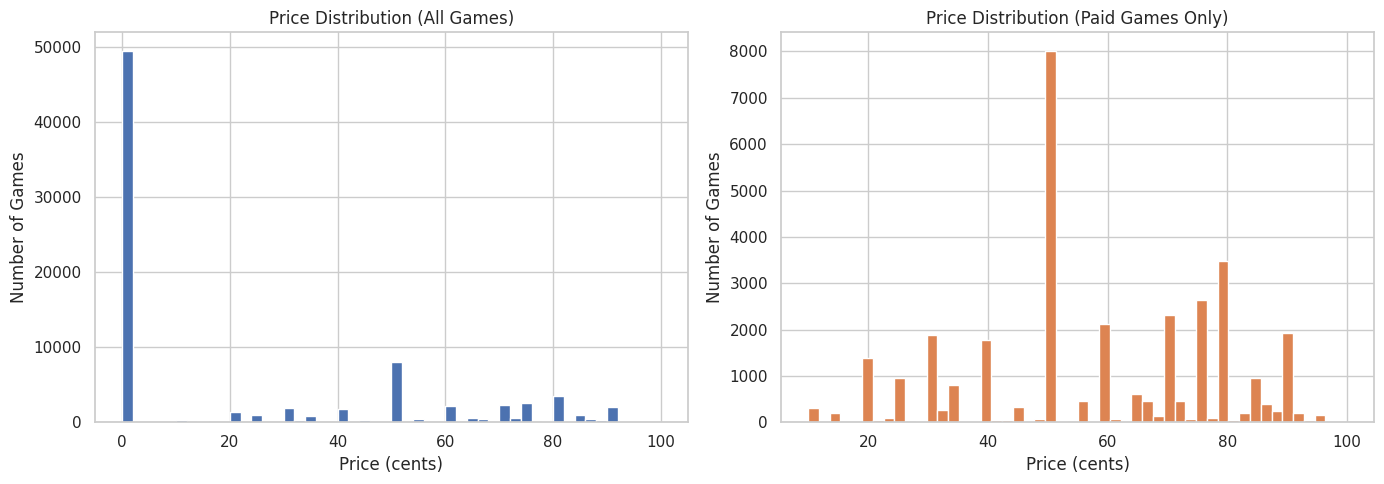

Saved: price_distribution.png


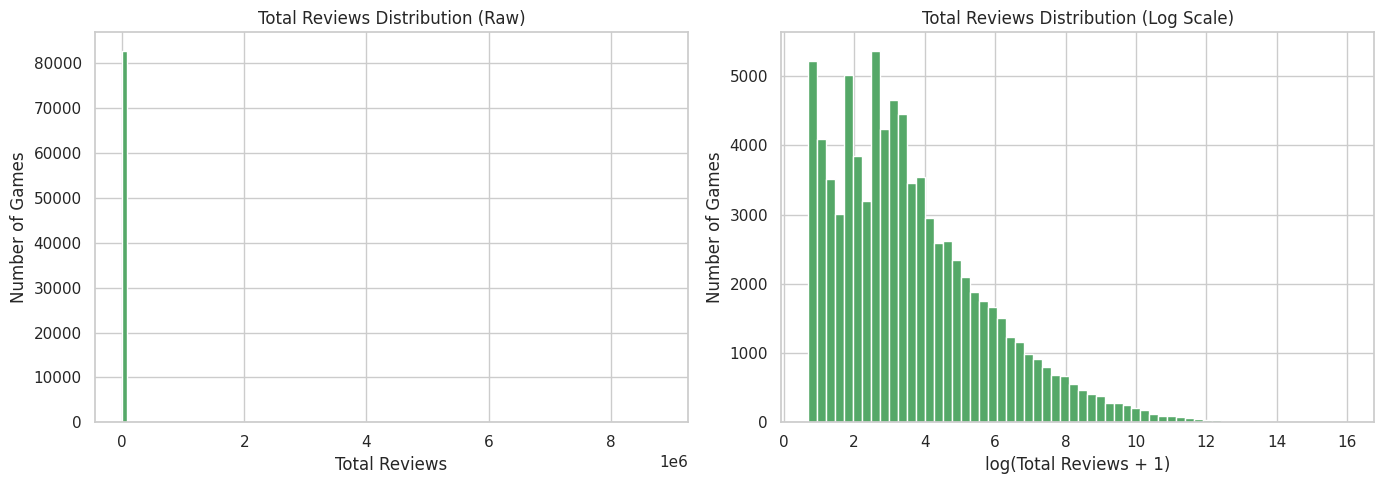

Saved: review_distribution.png


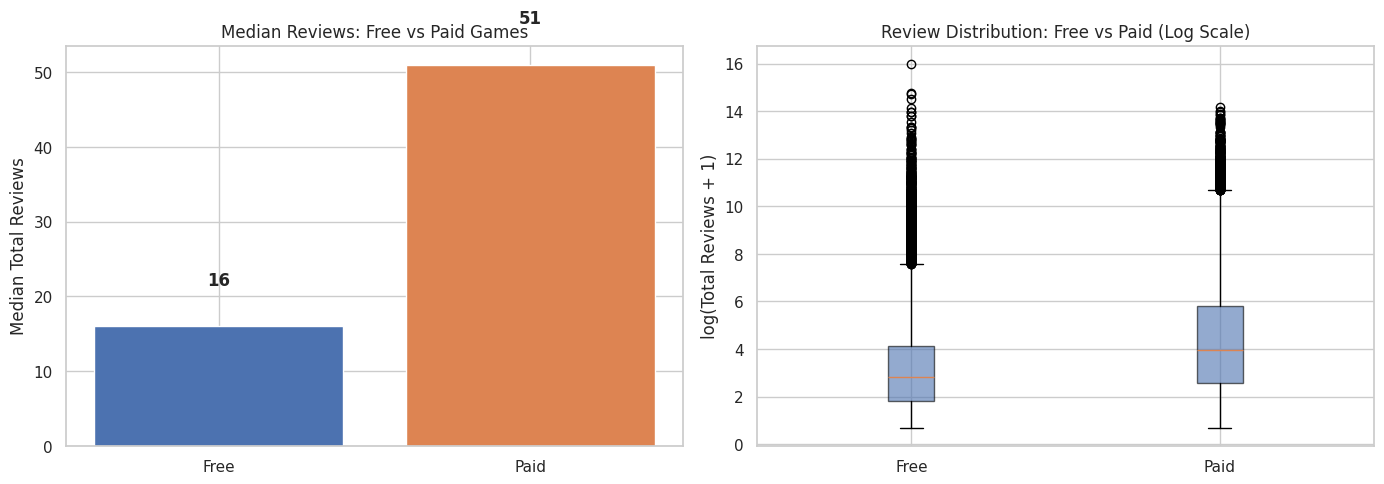

Saved: free_vs_paid.png


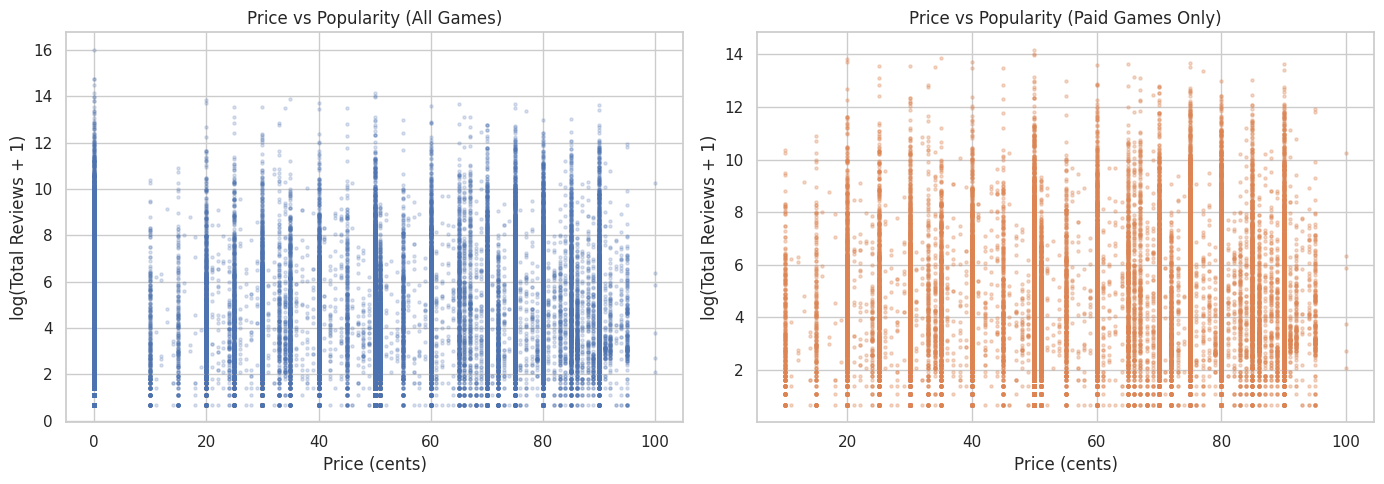

Saved: price_vs_popularity.png


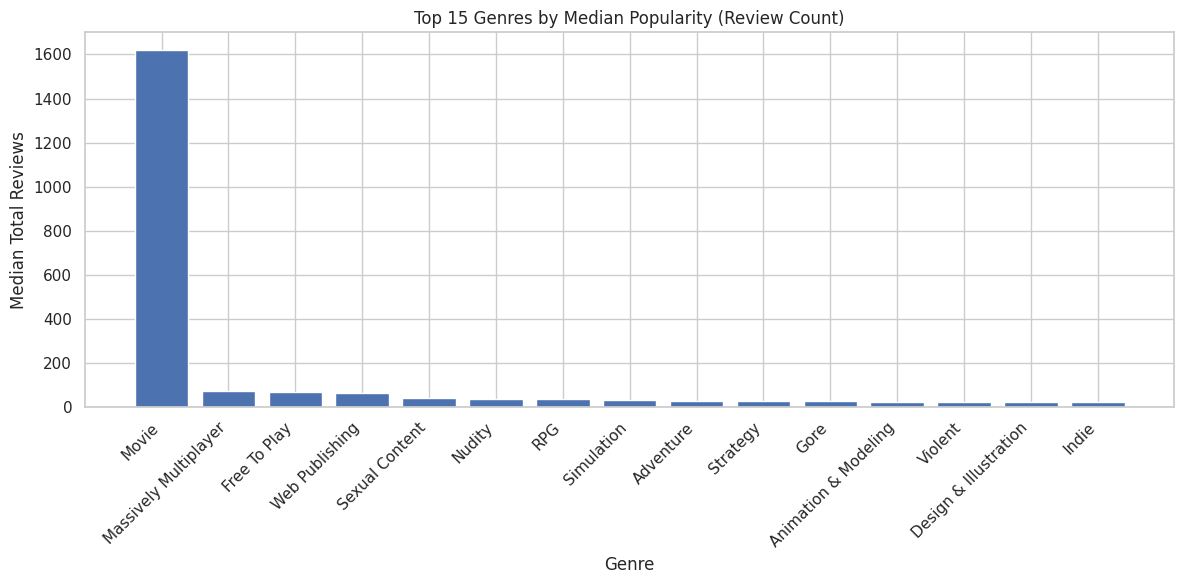

Saved: genre_popularity.png


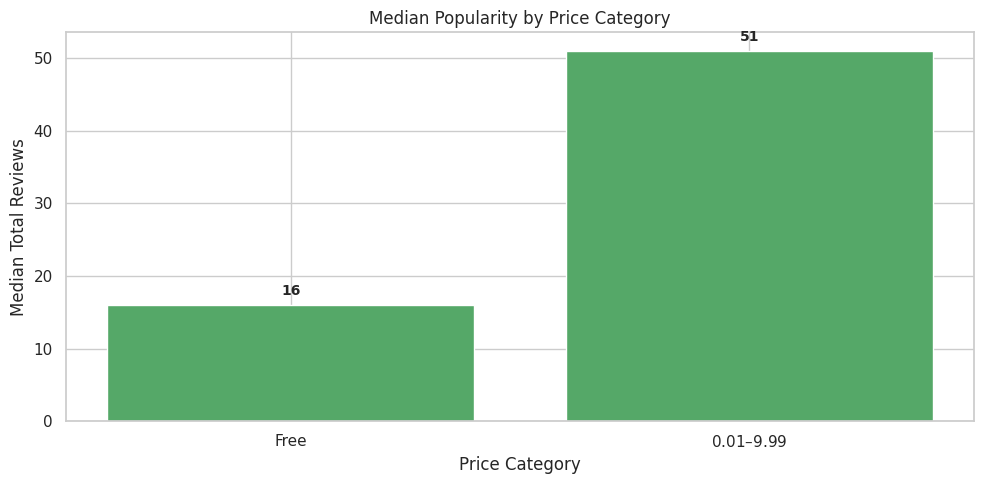

Saved: price_category_popularity.png


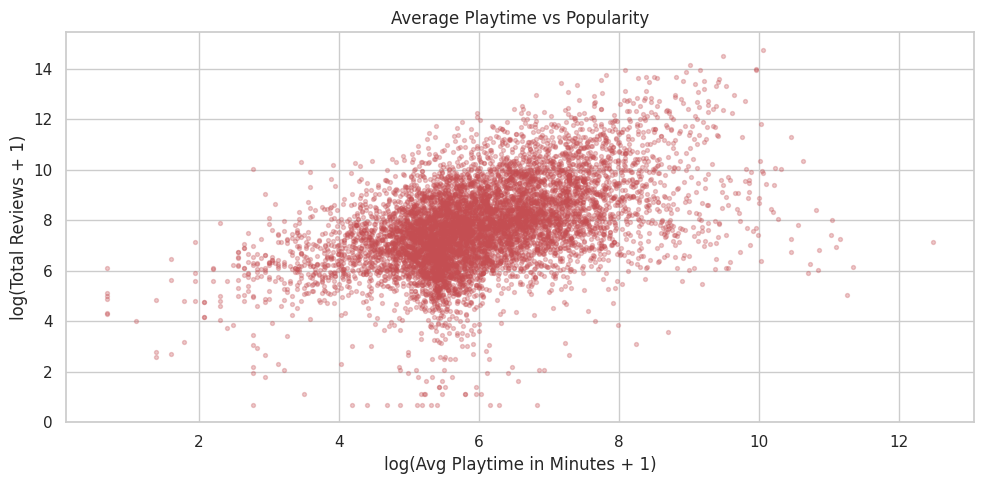

Saved: playtime_vs_popularity.png


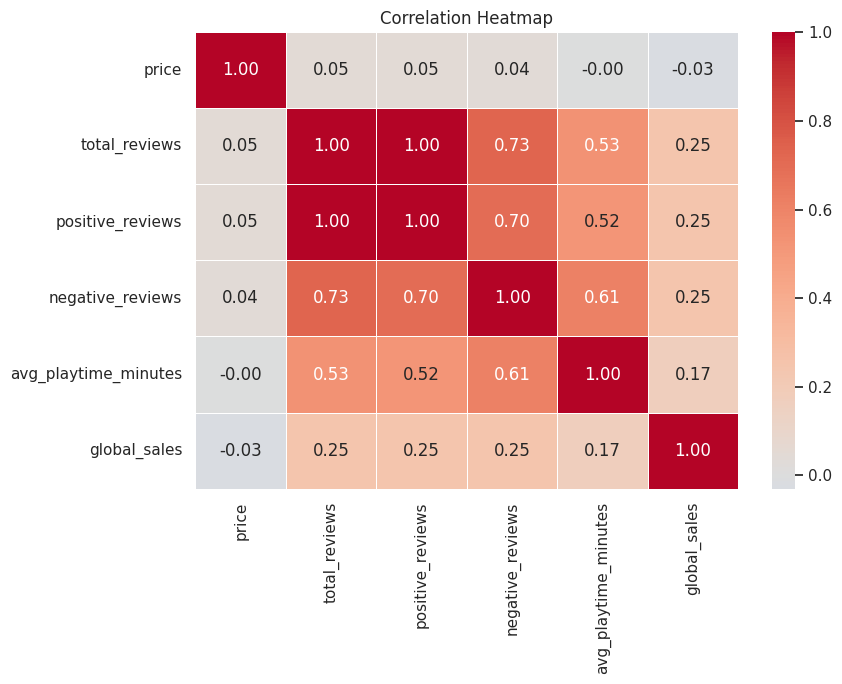

Saved: correlation_heatmap.png


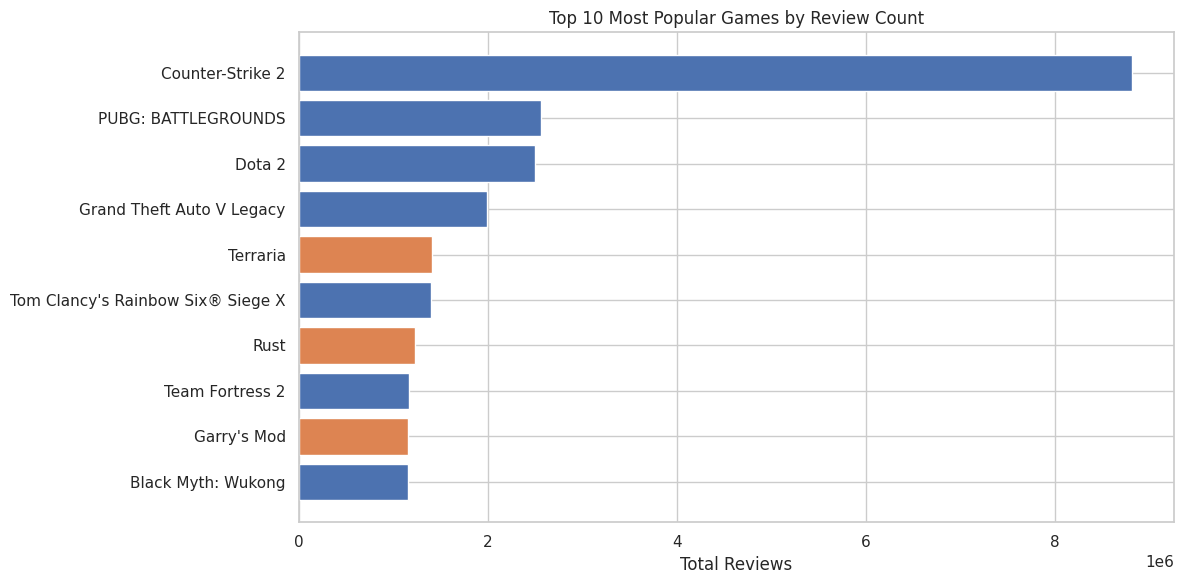

Saved: top10_games.png

EDA complete! All figures saved.


In [7]:

# Exploratory Data Analysis (EDA)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

# Load cleaned dataset
df = pd.read_csv("video_games_clean.csv")
print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")


# ============================================================
# 1. BASIC OVERVIEW
# ============================================================
print("\n--- Basic Overview ---")
print(df.describe().round(2))

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Free vs Paid Games ---")
print(df["is_free"].value_counts().rename({0: "Paid", 1: "Free"}))


# ============================================================
# 2. PRICE DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All games
axes[0].hist(df["price"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Price Distribution (All Games)")
axes[0].set_xlabel("Price (cents)")
axes[0].set_ylabel("Number of Games")

# Paid games only (price > 0)
paid = df[df["price"] > 0]
axes[1].hist(paid["price"], bins=50, color="#DD8452", edgecolor="white")
axes[1].set_title("Price Distribution (Paid Games Only)")
axes[1].set_xlabel("Price (cents)")
axes[1].set_ylabel("Number of Games")

plt.tight_layout()
plt.savefig("price_distribution.png", dpi=150)
plt.show()
print("Saved: price_distribution.png")


# ============================================================
# 3. POPULARITY (REVIEW COUNT) DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df["total_reviews"], bins=100, color="#55A868", edgecolor="white")
axes[0].set_title("Total Reviews Distribution (Raw)")
axes[0].set_xlabel("Total Reviews")
axes[0].set_ylabel("Number of Games")

# Log scale for better visibility
axes[1].hist(np.log1p(df["total_reviews"]), bins=60, color="#55A868", edgecolor="white")
axes[1].set_title("Total Reviews Distribution (Log Scale)")
axes[1].set_xlabel("log(Total Reviews + 1)")
axes[1].set_ylabel("Number of Games")

plt.tight_layout()
plt.savefig("review_distribution.png", dpi=150)
plt.show()
print("Saved: review_distribution.png")


# ============================================================
# 4. FREE vs PAID: POPULARITY COMPARISON
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

free = df[df["is_free"] == 1]["total_reviews"]
paid_reviews = df[df["is_free"] == 0]["total_reviews"]

# Median comparison
medians = [free.median(), paid_reviews.median()]
bars = axes[0].bar(["Free", "Paid"], medians, color=["#4C72B0", "#DD8452"], edgecolor="white")
axes[0].set_title("Median Reviews: Free vs Paid Games")
axes[0].set_ylabel("Median Total Reviews")
for bar, val in zip(bars, medians):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{int(val):,}", ha="center", va="bottom", fontweight="bold")

# Box plot
df["price_group"] = df["is_free"].map({1: "Free", 0: "Paid"})
axes[1].boxplot([np.log1p(free), np.log1p(paid_reviews)],
                labels=["Free", "Paid"], patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.6))
axes[1].set_title("Review Distribution: Free vs Paid (Log Scale)")
axes[1].set_ylabel("log(Total Reviews + 1)")

plt.tight_layout()
plt.savefig("free_vs_paid.png", dpi=150)
plt.show()
print("Saved: free_vs_paid.png")


# ============================================================
# 5. PRICE vs POPULARITY (SCATTER)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All games
axes[0].scatter(df["price"], np.log1p(df["total_reviews"]),
                alpha=0.2, s=5, color="#4C72B0")
axes[0].set_title("Price vs Popularity (All Games)")
axes[0].set_xlabel("Price (cents)")
axes[0].set_ylabel("log(Total Reviews + 1)")

# Paid games only
axes[1].scatter(paid["price"], np.log1p(paid["total_reviews"]),
                alpha=0.3, s=5, color="#DD8452")
axes[1].set_title("Price vs Popularity (Paid Games Only)")
axes[1].set_xlabel("Price (cents)")
axes[1].set_ylabel("log(Total Reviews + 1)")

plt.tight_layout()
plt.savefig("price_vs_popularity.png", dpi=150)
plt.show()
print("Saved: price_vs_popularity.png")


# ============================================================
# 6. TOP 10 GENRES BY POPULARITY
# ============================================================
# Explode genres (comma-separated)
genre_df = df.dropna(subset=["genres"]).copy()
genre_df = genre_df.assign(genre=genre_df["genres"].str.split(",")).explode("genre")
genre_df["genre"] = genre_df["genre"].str.strip()

# Average reviews per genre
genre_pop = genre_df.groupby("genre")["total_reviews"].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
bars = plt.bar(genre_pop.index, genre_pop.values, color="#4C72B0", edgecolor="white")
plt.title("Top 15 Genres by Median Popularity (Review Count)")
plt.xlabel("Genre")
plt.ylabel("Median Total Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("genre_popularity.png", dpi=150)
plt.show()
print("Saved: genre_popularity.png")


# ============================================================
# 7. PRICE CATEGORY vs POPULARITY
# ============================================================
# Create price categories
bins = [-1, 0, 999, 2999, 5999, 200000]
labels = ["Free", "$0.01–$9.99", "$10–$29.99", "$30–$59.99", "$60+"]
df["price_category"] = pd.cut(df["price"], bins=bins, labels=labels)

cat_pop = df.groupby("price_category", observed=True)["total_reviews"].median()

plt.figure(figsize=(10, 5))
bars = plt.bar(cat_pop.index, cat_pop.values, color="#55A868", edgecolor="white")
plt.title("Median Popularity by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Median Total Reviews")
for bar, val in zip(bars, cat_pop.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{int(val):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("price_category_popularity.png", dpi=150)
plt.show()
print("Saved: price_category_popularity.png")


# ============================================================
# 8. PLAYTIME vs POPULARITY
# ============================================================
spy_df = df.dropna(subset=["avg_playtime_minutes"])
spy_df = spy_df[spy_df["avg_playtime_minutes"] > 0]

plt.figure(figsize=(10, 5))
plt.scatter(np.log1p(spy_df["avg_playtime_minutes"]),
            np.log1p(spy_df["total_reviews"]),
            alpha=0.3, s=8, color="#C44E52")
plt.title("Average Playtime vs Popularity")
plt.xlabel("log(Avg Playtime in Minutes + 1)")
plt.ylabel("log(Total Reviews + 1)")
plt.tight_layout()
plt.savefig("playtime_vs_popularity.png", dpi=150)
plt.show()
print("Saved: playtime_vs_popularity.png")


# ============================================================
# 9. CORRELATION HEATMAP
# ============================================================
corr_cols = ["price", "total_reviews", "positive_reviews",
             "negative_reviews", "avg_playtime_minutes", "global_sales"]
corr_df = df[corr_cols].dropna()
corr_matrix = corr_df.corr().round(2)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0,
            linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")


# ============================================================
# 10. TOP 10 MOST POPULAR GAMES
# ============================================================
top10 = df.nlargest(10, "total_reviews")[["title", "price", "total_reviews", "is_free"]]
top10["price_label"] = top10.apply(
    lambda r: "Free" if r["is_free"] == 1 else f"${r['price']/100:.2f}", axis=1)

plt.figure(figsize=(12, 6))
colors = ["#4C72B0" if f == 1 else "#DD8452" for f in top10["is_free"]]
bars = plt.barh(top10["title"][::-1], top10["total_reviews"][::-1],
                color=colors[::-1], edgecolor="white")
plt.title("Top 10 Most Popular Games by Review Count")
plt.xlabel("Total Reviews")
plt.tight_layout()
plt.savefig("top10_games.png", dpi=150)
plt.show()
print("Saved: top10_games.png")

print("\nEDA complete! All figures saved.")